In [10]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

@jax.custom_jvp
def spectral_circulant_matmul(x: jnp.ndarray, fft_full: jnp.ndarray) -> jnp.ndarray:
    padded_dim = fft_full.shape[0]
    single_example = x.ndim == 1
    if single_example:
        x = x[None, :]
    d_in = x.shape[-1]
    if d_in < padded_dim:
        pad_len = padded_dim - d_in
        x_pad = jnp.pad(x, ((0, 0), (0, pad_len)))
    elif d_in > padded_dim:
        x_pad = x[..., :padded_dim]
    else:
        x_pad = x
    X_fft = jnp.fft.fft(x_pad, axis=-1)
    y_fft = X_fft * fft_full[None, :]
    y = jnp.fft.ifft(y_fft, axis=-1).real
    if single_example:
        return y[0]
    return y

@spectral_circulant_matmul.defjvp
def spectral_circulant_matmul_jvp(primals, tangents):
    x, fft_full = primals
    dx, dfft = tangents
    padded_dim = fft_full.shape[0]

    single_example = x.ndim == 1
    if single_example:
        x = x[None, :]
        if dx is not None:
            dx = dx[None, :]
    d_in = x.shape[-1]
    if d_in < padded_dim:
        pad_len = padded_dim - d_in
        x_pad = jnp.pad(x, ((0, 0), (0, pad_len)))
        dx_pad = jnp.pad(dx, ((0, 0), (0, pad_len))) if dx is not None else None
    elif d_in > padded_dim:
        x_pad = x[..., :padded_dim]
        dx_pad = dx[..., :padded_dim] if dx is not None else None
    else:
        x_pad = x
        dx_pad = dx

    X_fft = jnp.fft.fft(x_pad, axis=-1)
    primal_y_fft = X_fft * fft_full[None, :]
    primal_y = jnp.fft.ifft(primal_y_fft, axis=-1).real

    if dx_pad is None:
        dX_fft = 0.0
    else:
        dX_fft = jnp.fft.fft(dx_pad, axis=-1)
    if dfft is None:
        term2 = 0.0
    else:
        term2 = X_fft * dfft[None, :]
    dY_fft = dX_fft * fft_full[None, :] + term2
    dY = jnp.fft.ifft(dY_fft, axis=-1).real

    if single_example:
        return primal_y[0], dY[0]
    return primal_y, dY

class SpectralCirculantLayer:
    def __init__(
        self,
        in_features: int,
        padded_dim: int = None,
        kernel_type: str = "power",
        alpha: float = None,
        alpha_prior=dist.HalfNormal(1),
        K: int = None,
        name: str = "spectral_circ_jvp",
        prior_fn=None,
        **kernel_kwargs
    ):
        """
        :param in_features: Input dimension.
        :param padded_dim: If provided, pad/truncate inputs to this dimension.
        :param kernel_type: Type of spectral density to use ("power", "rbf", "matern32", "matern52").
        :param alpha: For the "power" kernel, fixed value for the decay exponent; if None, a hyperprior is used.
        :param alpha_prior: Prior distribution for alpha if it is not fixed.
        :param K: Number of active frequencies to keep; if None, use full half-spectrum.
        :param name: Base name for NumPyro sample sites.
        :param prior_fn: Function mapping a scale to a distribution (default: Normal(0, scale)).
        :param kernel_kwargs: Additional parameters for the chosen kernel type (e.g. length_scale, variance, etc.).
        """
        self.in_features = in_features
        self.padded_dim = padded_dim if padded_dim is not None else in_features
        self.kernel_type = kernel_type.lower()
        self.alpha = alpha
        self.alpha_prior = alpha_prior
        self.name = name
        self.kernel_kwargs = kernel_kwargs

        # Length of half spectrum including DC (and Nyquist when applicable)
        self.k_half = (self.padded_dim // 2) + 1
        if (K is None) or (K > self.k_half):
            K = self.k_half
        self.K = K

        self.prior_fn = prior_fn if prior_fn is not None else (lambda scale: dist.Normal(0.0, scale))
        self._last_fft_full = None

    def compute_psd(self, freq_idx):
        """
        Compute the power spectral density (PSD) for a given array of frequency indices.
        Returns a vector of nonnegative values representing the variance allocated at each frequency.
        """
        if self.kernel_type == "power":
            # Use a power-law decay: PSD = 1 / (1 + f^alpha)
            if self.alpha is None:
                alpha = numpyro.sample(f"{self.name}_alpha", self.alpha_prior)
            else:
                alpha = self.alpha
            psd = 1.0 / (1.0 + freq_idx**alpha)
        elif self.kernel_type == "rbf":
            # PSD for RBF kernel: PSD = variance * exp(-2*pi^2*length_scale^2*f^2)
            length_scale = self.kernel_kwargs.get("length_scale", 1.0)
            variance = self.kernel_kwargs.get("variance", 1.0)
            psd = variance * jnp.exp(-2 * (jnp.pi**2) * (length_scale**2) * (freq_idx**2))
        elif self.kernel_type == "matern32":
            # A variant for Matern 3/2 kernel PSD:
            # PSD ∝ variance / (1 + (2*pi*length_scale*f)^2)^(2)
            length_scale = self.kernel_kwargs.get("length_scale", 1.0)
            variance = self.kernel_kwargs.get("variance", 1.0)
            psd = variance / (1.0 + (2*jnp.pi*length_scale*freq_idx)**2)**2
        elif self.kernel_type == "matern52":
            # A variant for Matern 5/2 kernel PSD:
            # PSD ∝ variance / (1 + (2*pi*length_scale*f)^2 + (2*pi*length_scale*f)^4)^(?)
            # This is one possible form.
            length_scale = self.kernel_kwargs.get("length_scale", 1.0)
            variance = self.kernel_kwargs.get("variance", 1.0)
            psd = variance / (1.0 + (2*jnp.pi*length_scale*freq_idx)**2 + (2*jnp.pi*length_scale*freq_idx)**4)
        else:
            raise ValueError(f"Unknown kernel type: {self.kernel_type}")
        return psd

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        # Sample or fix alpha (only used in "power" kernel)
        if self.kernel_type == "power":
            if self.alpha is None:
                alpha = numpyro.sample(f"{self.name}_alpha", self.alpha_prior)
            else:
                alpha = self.alpha
        # Frequency indices for half spectrum
        freq_idx = jnp.arange(self.k_half, dtype=jnp.float32)
        # Compute theoretical PSD for these frequencies.
        theoretical_psd = self.compute_psd(freq_idx)
        # Convert PSD to standard deviations for the Gaussian prior:
        prior_std = jnp.sqrt(theoretical_psd)
        prior_std = jnp.clip(prior_std, a_min=1e-6)  # ensure no zero scales
        
        # Only sample active frequencies (truncation)
        active_idx = jnp.arange(self.K)
        active_real = numpyro.sample(
            f"{self.name}_real",
            self.prior_fn(prior_std[active_idx]).expand([self.K]).to_event(1),
        )
        active_imag = numpyro.sample(
            f"{self.name}_imag",
            self.prior_fn(prior_std[active_idx]).expand([self.K]).to_event(1),
        )

        # Construct full half-spectrum (fill unused frequencies with zero)
        full_real = jnp.zeros((self.k_half,), dtype=jnp.float32)
        full_imag = jnp.zeros((self.k_half,), dtype=jnp.float32)
        full_real = full_real.at[active_idx].set(active_real)
        full_imag = full_imag.at[active_idx].set(active_imag)

        # Enforce real-valued DC and (if even) Nyquist terms
        full_imag = full_imag.at[0].set(0.0)
        if (self.padded_dim % 2 == 0) and (self.k_half > 1):
            full_imag = full_imag.at[-1].set(0.0)

        half_complex = full_real + 1j * full_imag

        # Construct full Fourier coefficients via Hermitian symmetry
        if (self.padded_dim % 2 == 0) and (self.k_half > 1):
            nyquist = half_complex[-1].real[None]
            fft_full = jnp.concatenate(
                [half_complex[:-1], nyquist, jnp.conjugate(half_complex[1:-1])[::-1]]
            )
        else:
            fft_full = jnp.concatenate(
                [half_complex, jnp.conjugate(half_complex[1:])[::-1]]
            )

        self._last_fft_full = jax.lax.stop_gradient(fft_full)

        # Sample bias and add to output.
        bias = numpyro.sample(
            f"{self.name}_bias_spectral",
            dist.Normal(0.0, 1.0).expand([self.padded_dim]).to_event(1),
        )
        out = spectral_circulant_matmul(x, fft_full) + bias
        return out

    def get_fourier_coeffs(self) -> jnp.ndarray:
        if self._last_fft_full is None:
            raise ValueError("No Fourier coefficients available; call the layer first.")
        return self._last_fft_full

    def compute_covariance_kernel(self):
        """
        Compute the theoretical covariance kernel using the inverse FFT of the
        theoretical PSD. Here, the PSD is defined as that from compute_psd().
        This kernel represents the autocovariance function of the GP.
        """
        if self.kernel_type == "power" and self.alpha is None:
            raise ValueError("Alpha must be set to compute the covariance kernel.")
        freq_idx = jnp.arange(self.k_half, dtype=jnp.float32)
        theoretical_psd = self.compute_psd(freq_idx)
    
        # Build a full PSD vector with Hermitian symmetry.
        if (self.padded_dim % 2 == 0) and (self.k_half > 1):
            nyquist = theoretical_psd[-1][None]
            full_psd = jnp.concatenate(
                [theoretical_psd[:-1], nyquist, jnp.conjugate(theoretical_psd[1:-1])[::-1]]
            )
        else:
            full_psd = jnp.concatenate(
                [theoretical_psd, jnp.conjugate(theoretical_psd[1:])[::-1]]
            )
    
        # Compute the autocovariance function (kernel) via the inverse FFT of the PSD.
        kernel = jnp.fft.ifft(full_psd).real
        return kernel


In [19]:
import jax
import jax.random as jr
import numpy as np 
import time 
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

from quantbayes import bnn
from quantbayes.fake_data import generate_regression_data 
from quantbayes.bnn.utils import BayesianAnalysis, evaluate_mcmc

df = generate_regression_data(n_continuous=64)
X, y = df.drop("target", axis=1), df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)
X_train = jnp.array(X_train)
X_test = jnp.array(X_test)
y_train = jnp.array(y_train)
y_test = jnp.array(y_test)

class Test(bnn.Module):
    def __init__(self):
        super().__init__()
        self.fft_layer = SpectralCirculantLayer(
            64, 
            alpha=0.5,
            kernel_type="matern52",
            )
    def __call__(self, X, y=None):
        N, D = X.shape
        X = self.fft_layer(X)
        X = jax.nn.tanh(X)
        X = bnn.Linear(D, 1)(X)
        mu = X.squeeze()
        sigma = numpyro.sample("sigma", dist.Exponential(1.0))
        with numpyro.plate("data", N):
            numpyro.sample("logits", dist.Normal(mu, sigma), obs=y)

key = jr.key(0)
model = Test()
model.compile(num_warmup=300, num_samples=500)
tak = time.time()
model.fit(X_train, y_train, key)
tik = time.time()
preds = model.predict(X_test, key)
mean_preds = preds.mean(axis=0)
mse = mean_squared_error(np.array(y_test), np.array(mean_preds))
diagnostics = evaluate_mcmc(model)
bound = BayesianAnalysis(len(X_train), inference_type="mcmc", posterior_samples=model.get_samples)
bound.compute_pac_bayesian_bound(preds, y_test)
print(f"MSE: {mse:.3f}")
print(f"Time taken: {tik-tak:.3f}")
for key, value in diagnostics.items():
    print(key)
    print(value)

sample: 100%|██████████| 800/800 [02:58<00:00,  4.48it/s, 1023 steps of size 7.64e-04. acc. prob=0.92]
/Users/josephmargaryan/Desktop/quantbayes/venv/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


Empirical risk: 0.082
Confidence term: 0.718
KL-Divergence: 822.588
Pac-Bayes Bound: 0.801
MSE: 0.042
Time taken: 178.786
elpd_waic
142.46
p_waic
17.73
waic_se
0.03
elpd_loo
142.30
p_loo
17.89
loo_se
0.03
avg_rhat
NaN
avg_ess
224.18
total_params
196


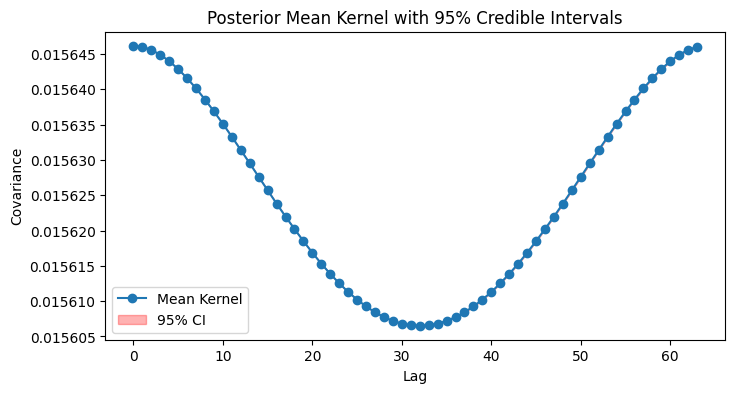

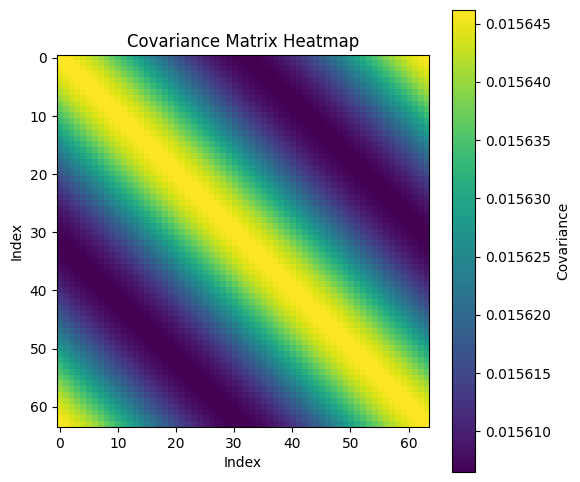

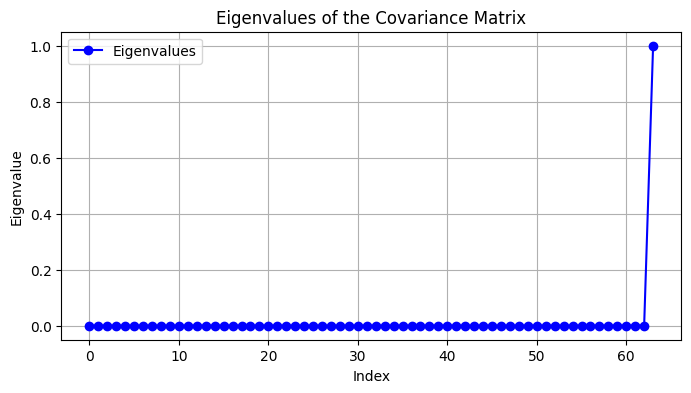

Minimum eigenvalue: -1.10827386e-07
Cholesky decomposition failed. The matrix might not be positive semidefinite.


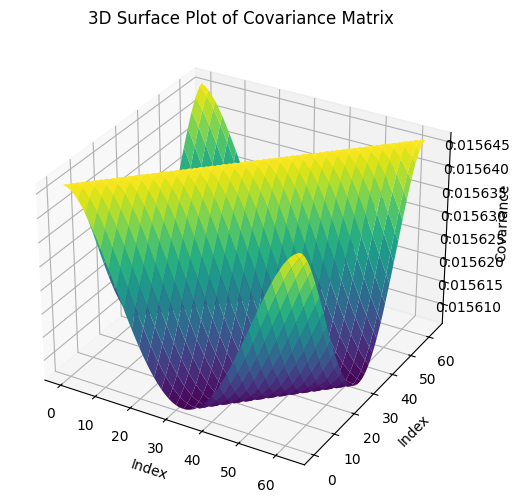

/var/folders/ch/74rww8ps6cx8x_ptd9fj5d400000gn/T/ipykernel_14615/3592259608.py:92: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = np.random.multivariate_normal(mean, cov_matrix, size=n_samples)


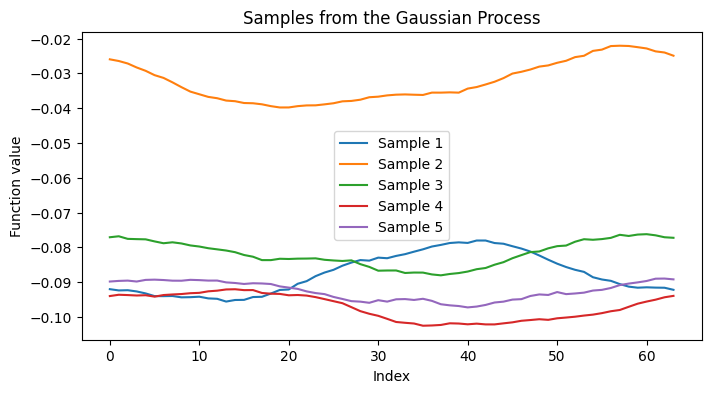

In [20]:
from numpyro import handlers
import jax.random as jr
import numpy as np
from scipy.linalg import toeplitz, cholesky, LinAlgError

def get_kernel_for_params(model, X, param_dict, rng_key=jr.PRNGKey(0)):
    """
    Substitute a concrete parameter set into the model and run one forward pass
    with a provided rng_key so that the sample sites receive valid keys.
    This triggers model.fft_layer to store its Fourier coefficients, from which
    we retrieve the kernel.
    """
    with handlers.seed(rng_seed=rng_key):
        with handlers.substitute(data=param_dict):
            _ = model(X)  # Run forward pass to set up Fourier coefficients.
    kernel = model.fft_layer.compute_covariance_kernel()
    return jax.device_get(kernel)

# Example: Collect kernel samples from posterior.
n_samples = 50  # number of posterior draws to analyze.
kernel_samples = []
posterior_samples = model.get_samples
for i in range(n_samples):
    sample_param_dict = {k: v[i] for k, v in posterior_samples.items()}
    kernel_sample = get_kernel_for_params(model, X_test, sample_param_dict, rng_key=jr.PRNGKey(i))
    kernel_samples.append(kernel_sample)
kernel_samples = np.stack(kernel_samples, axis=0)

# Compute the mean kernel and 95% credible intervals at each lag.
kernel_mean = np.mean(kernel_samples, axis=0)
kernel_lower = np.percentile(kernel_samples, 2.5, axis=0)
kernel_upper = np.percentile(kernel_samples, 97.5, axis=0)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(kernel_mean, label="Mean Kernel", marker="o")
plt.fill_between(np.arange(len(kernel_mean)), kernel_lower, kernel_upper, color="red", alpha=0.3, label="95% CI")
plt.xlabel("Lag")
plt.ylabel("Covariance")
plt.title("Posterior Mean Kernel with 95% Credible Intervals")
plt.legend()
plt.show()

cov_matrix = toeplitz(kernel_mean)

# 2. Heatmap of the covariance matrix.
plt.figure(figsize=(6, 6))
plt.imshow(cov_matrix, cmap="viridis", interpolation="none")
plt.title("Covariance Matrix Heatmap")
plt.xlabel("Index")
plt.ylabel("Index")
plt.colorbar(label="Covariance")
plt.show()

# 3. Eigenvalue Analysis: Plot the eigenvalues.
eigvals = np.linalg.eigvalsh(cov_matrix)
plt.figure(figsize=(8, 4))
plt.plot(eigvals, "bo-", label="Eigenvalues")
plt.title("Eigenvalues of the Covariance Matrix")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.legend()
plt.grid(True)
plt.show()

print("Minimum eigenvalue:", eigvals.min())

# 4. Cholesky Decomposition:
try:
    L = cholesky(cov_matrix, lower=True)
    print("Cholesky decomposition succeeded. The matrix is positive semidefinite.")
except LinAlgError:
    print("Cholesky decomposition failed. The matrix might not be positive semidefinite.")

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
n = cov_matrix.shape[0]
X_grid, Y_grid = np.meshgrid(np.arange(n), np.arange(n))
ax.plot_surface(X_grid, Y_grid, cov_matrix, cmap="viridis", edgecolor="none")
ax.set_title("3D Surface Plot of Covariance Matrix")
ax.set_xlabel("Index")
ax.set_ylabel("Index")
ax.set_zlabel("Covariance")
plt.show()

# 5. Generate sample functions from the Gaussian process defined by the kernel.
# Here, we assume zero mean for simplicity.
n_points = len(kernel_mean)
n_samples = 5  # number of GP samples to generate
mean = np.zeros(n_points)
samples = np.random.multivariate_normal(mean, cov_matrix, size=n_samples)

plt.figure(figsize=(8, 4))
for i in range(n_samples):
    plt.plot(samples[i], label=f"Sample {i+1}")
plt.title("Samples from the Gaussian Process")
plt.xlabel("Index")
plt.ylabel("Function value")
plt.legend()
plt.show()

## Training evolution of fourier magnitudes 

Epoch  100 | Train Loss: 41.5862 | Val Loss: 42.2437
Epoch  200 | Train Loss: 5.8463 | Val Loss: 6.1123
Epoch  300 | Train Loss: 2.2117 | Val Loss: 2.3350
Epoch  400 | Train Loss: 0.9698 | Val Loss: 1.0107
Epoch  500 | Train Loss: 0.5010 | Val Loss: 0.5179
Epoch  600 | Train Loss: 0.2882 | Val Loss: 0.3003
Epoch  700 | Train Loss: 0.1790 | Val Loss: 0.1884
Epoch  800 | Train Loss: 0.1188 | Val Loss: 0.1260
Epoch  900 | Train Loss: 0.0833 | Val Loss: 0.0884
Epoch 1000 | Train Loss: 0.0624 | Val Loss: 0.0679


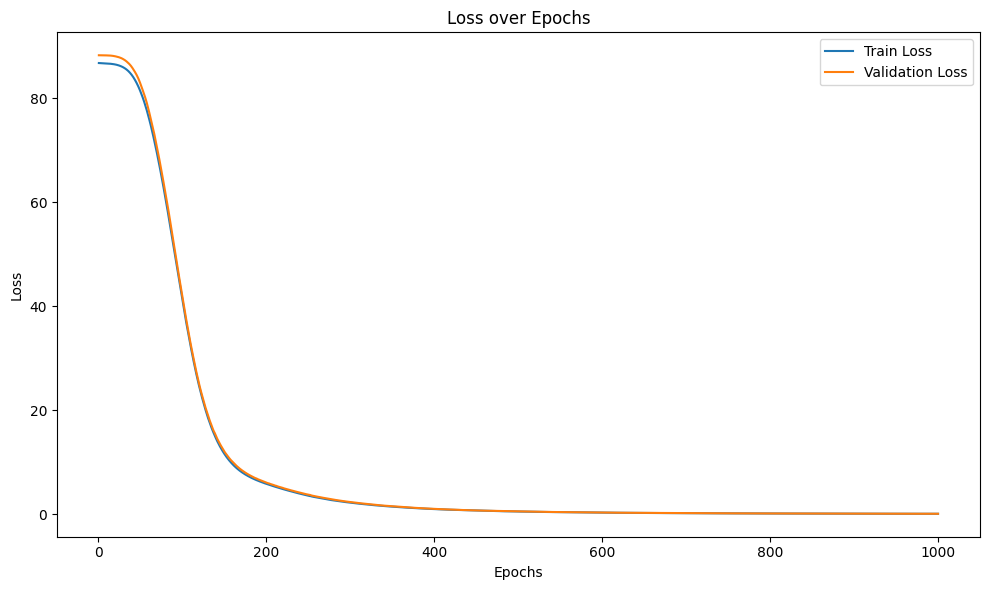

Test Loss (MSE): 0.067


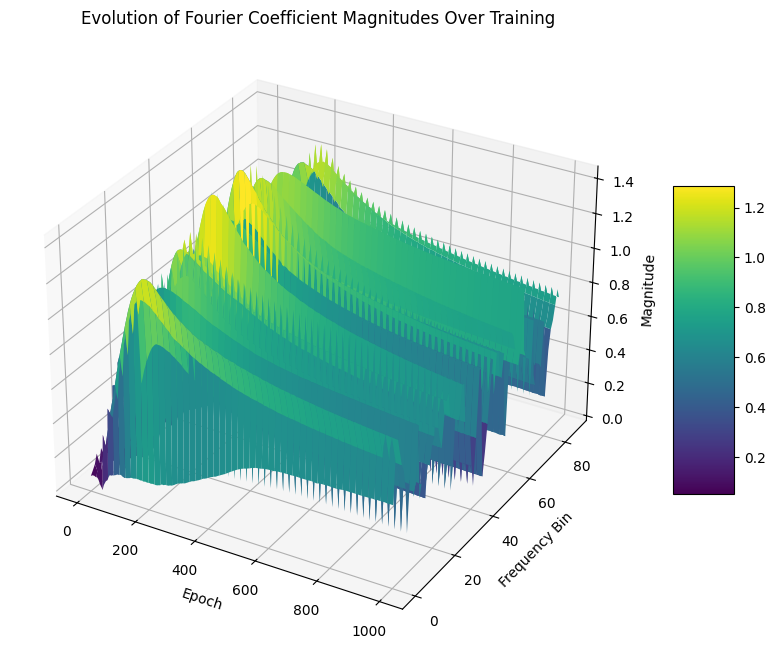

In [11]:
import copy
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax

from quantbayes.stochax.layers import CirculantProcess

# =============================================================================
# Data Loading Utilities
# =============================================================================
def data_loader(X, y, batch_size, shuffle=True, key=None):
    """
    Generator that yields minibatches from X and y.
    """
    n = X.shape[0]
    indices = jnp.arange(n)
    if shuffle:
        if key is None:
            raise ValueError("Shuffling requested but no key provided.")
        indices = jr.permutation(key, indices)
    for i in range(0, n, batch_size):
        batch_idx = indices[i : i + batch_size]
        yield X[batch_idx], y[batch_idx]

# =============================================================================
# Loss Function & Training Steps for Regression
# =============================================================================
def regression_loss(model, state, x, y, key):
    """
    Mean Squared Error (MSE) loss for regression tasks.
    """
    batch_size = x.shape[0]
    keys = jr.split(key, batch_size)
    batched_model = jax.vmap(model, in_axes=(0, None, None))
    preds, state = batched_model(x, key, state)
    loss = jnp.mean((preds - y) ** 2)
    return loss, state

@eqx.filter_jit
def train_step(model, state, opt_state, x, y, key, loss_fn, optimizer):
    """
    Generic training step.
    """
    grad_fn = eqx.filter_grad(loss_fn, has_aux=True)
    grads, new_state = grad_fn(model, state, x, y, key)
    params = eqx.filter(model, eqx.is_inexact_array)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    model = eqx.apply_updates(model, updates)
    return model, new_state, opt_state

@eqx.filter_jit
def eval_step(model, state, x, y, key, loss_fn):
    """
    Generic evaluation step returning the loss.
    """
    loss, _ = loss_fn(model, state, x, y, key)
    return loss

# =============================================================================
# Modified Training Loop (logging spectral dynamics)
# =============================================================================
def train(
    model,
    state,
    opt_state,
    optimizer,
    loss_fn,
    X_train,
    y_train,
    X_val,
    y_val,
    batch_size,
    num_epochs,
    patience,
    key,
):
    """
    Training loop with early stopping and logging of spectral magnitudes from model.l1.
    """
    train_losses = []
    val_losses = []
    best_val_loss = float("inf")
    best_model = None
    best_state = None
    patience_counter = 0

    # List to record Fourier coefficient magnitudes for model.l1 each epoch.
    spectral_history = []

    # Split key for training and evaluation.
    train_key, eval_key = jr.split(key)
    for epoch in range(num_epochs):
        epoch_train_loss = 0.0
        total_train_samples = 0
        train_key, loader_key = jr.split(train_key)
        for xb, yb in data_loader(X_train, y_train, batch_size, shuffle=True, key=loader_key):
            train_key, subkey = jr.split(train_key)
            model, state, opt_state = train_step(
                model, state, opt_state, xb, yb, subkey, loss_fn, optimizer
            )
            loss_val, _ = loss_fn(model, state, xb, yb, subkey)
            epoch_train_loss += loss_val * xb.shape[0]
            total_train_samples += xb.shape[0]
        epoch_train_loss /= total_train_samples

        # Evaluation loop
        epoch_val_loss = 0.0
        total_val_samples = 0
        for xb, yb in data_loader(X_val, y_val, batch_size, shuffle=False, key=eval_key):
            eval_key, subkey = jr.split(eval_key)
            loss_val = eval_step(model, state, xb, yb, subkey, loss_fn)
            epoch_val_loss += loss_val * xb.shape[0]
            total_val_samples += xb.shape[0]
        epoch_val_loss /= total_val_samples

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)

        # Log spectral magnitudes from the first layer (CirculantProcess)
        fft_coeffs = model.l1.get_fourier_coeffs()  # Assumes deterministic coefficients.
        spectral_mag = jnp.abs(fft_coeffs)  # Compute magnitude.
        spectral_history.append(np.array(spectral_mag))  # Convert to NumPy array.

        if (epoch + 1) % max(1, num_epochs // 10) == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch+1:4d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

        # Early stopping and checkpointing.
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model = copy.deepcopy(model)
            best_state = copy.deepcopy(state)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter > patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    return best_model, best_state, train_losses, val_losses, spectral_history

# =============================================================================
# Prediction Function
# =============================================================================
def predict(model, state, X, key):
    """
    Predict function for computing model outputs for input data.
    """
    batched_inference = jax.vmap(model, in_axes=(0, None, None))
    logits, _ = batched_inference(X, key, state)
    return logits

# =============================================================================
# Neural Network Definition (using your CirculantProcess layer)
# =============================================================================
class EQNet1(eqx.Module):
    l1: eqx.Module  # This should be your custom CirculantProcess layer.
    l2: eqx.Module  # Another CirculantProcess layer.
    l3: eqx.Module  # A linear layer.

    def __init__(self, key):
        # Split the key for each module.
        k1, k2, k3, _ = jr.split(key, 4)
        # Assume CirculantProcess is already defined and imported.
        self.l1 = CirculantProcess(87, key=k1)
        self.l2 = CirculantProcess(87, key=k3)
        self.l3 = eqx.nn.Linear(87, 1, key=k2)

    def __call__(self, x, key=None, state=None):
        x = self.l1(x)
        x = jax.nn.relu(x)
        x = self.l2(x)
        x = jax.nn.relu(x)
        x = self.l3(x)
        return x, state

# =============================================================================
# Synthetic Data Generation and Experiment Runner
# =============================================================================
# For reproducibility.
np.random.seed(42)

# Generate synthetic regression data.
num_samples = 10000
in_features = 87
# Create random input features.
X_full = np.random.randn(num_samples, in_features).astype(np.float32)
# Create targets with a linear relationship and some noise.
true_weights = np.random.randn(in_features, 1).astype(np.float32)
y_full = X_full @ true_weights + 0.1 * np.random.randn(num_samples, 1).astype(np.float32)

# Split into training and test datasets.
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2)
X_train = jnp.array(X_train)
X_test = jnp.array(X_test)
y_train = jnp.array(y_train)
y_test = jnp.array(y_test)

# =============================================================================
# Initialize Model, Optimizer, and Train
# =============================================================================
key = jr.PRNGKey(0)
model = EQNet1(key=key)
state = None
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

# Train model and record spectral history.
best_model, best_state, train_losses, val_losses, spectral_history = train(
    model=model,
    state=state,
    opt_state=opt_state,
    optimizer=optimizer,
    loss_fn=regression_loss,
    X_train=X_train,
    y_train=y_train,
    X_val=X_test,
    y_val=y_test,
    batch_size=2500,
    num_epochs=1000,
    patience=10,
    key=key,
)

# =============================================================================
# Evaluate & Visualize Losses
# =============================================================================
# Set model into inference mode if needed.
inference_model = eqx.nn.inference_mode(best_model)
preds = predict(best_model, best_state, X_test, key)
loss = mean_squared_error(np.array(y_test), np.array(preds))

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(train_losses) + 1), np.array(train_losses), label="Train Loss")
plt.plot(np.arange(1, len(val_losses) + 1), np.array(val_losses), label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Test Loss (MSE): {loss:.3f}")

# =============================================================================
# Visualize the Evolution of Fourier Magnitude (Spectral Dynamics)
# =============================================================================
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D  # For 3D plotting

# Convert spectral_history to a NumPy array (shape: [epochs, padded_dim]).
spectral_history = np.array(spectral_history)
num_epochs_recorded, padded_dim = spectral_history.shape

# Create a meshgrid for plotting: epochs (x-axis) and frequency bins (y-axis).
epochs_axis = np.arange(1, num_epochs_recorded + 1)
freq_axis = np.arange(padded_dim)
Epochs, Freq = np.meshgrid(epochs_axis, freq_axis, indexing='ij')

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(Epochs, Freq, spectral_history, cmap=cm.viridis)
ax.set_xlabel("Epoch")
ax.set_ylabel("Frequency Bin")
ax.set_zlabel("Magnitude")
ax.set_title("Evolution of Fourier Coefficient Magnitudes Over Training")
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()


## Loss landscape and curvature comparison between Spectral and Dense

Training Spectral Model:
Epoch  100 | Train Loss: 43.3422 | Val Loss: 44.6003
Epoch  200 | Train Loss: 5.5188 | Val Loss: 5.5284
Epoch  300 | Train Loss: 2.0510 | Val Loss: 2.0991
Epoch  400 | Train Loss: 0.9009 | Val Loss: 0.9531
Epoch  500 | Train Loss: 0.4717 | Val Loss: 0.5050
Epoch  600 | Train Loss: 0.2747 | Val Loss: 0.2900
Epoch  700 | Train Loss: 0.1698 | Val Loss: 0.1780
Epoch  800 | Train Loss: 0.1103 | Val Loss: 0.1169
Epoch  900 | Train Loss: 0.0758 | Val Loss: 0.0814
Epoch 1000 | Train Loss: 0.0541 | Val Loss: 0.0601

Training Dense Model:
Epoch  100 | Train Loss: 0.0769 | Val Loss: 0.1532
Epoch  200 | Train Loss: 0.0310 | Val Loss: 0.1045
Epoch  300 | Train Loss: 0.0173 | Val Loss: 0.0841
Epoch  400 | Train Loss: 0.0114 | Val Loss: 0.0733
Epoch  500 | Train Loss: 0.0084 | Val Loss: 0.0679
Early stopping at epoch 519
Spectral Model MSE: 0.060
Dense Model MSE:    0.067


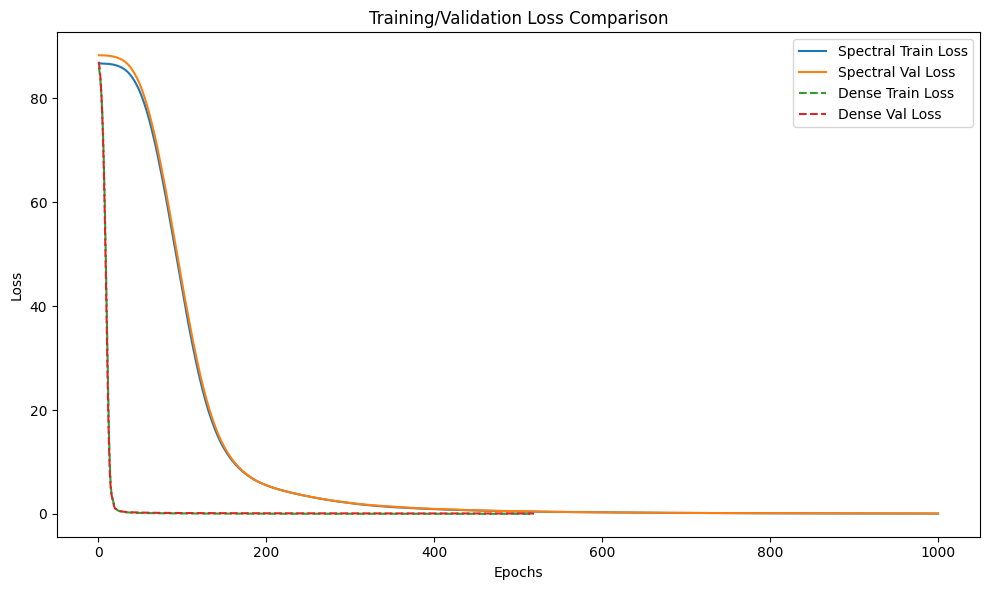

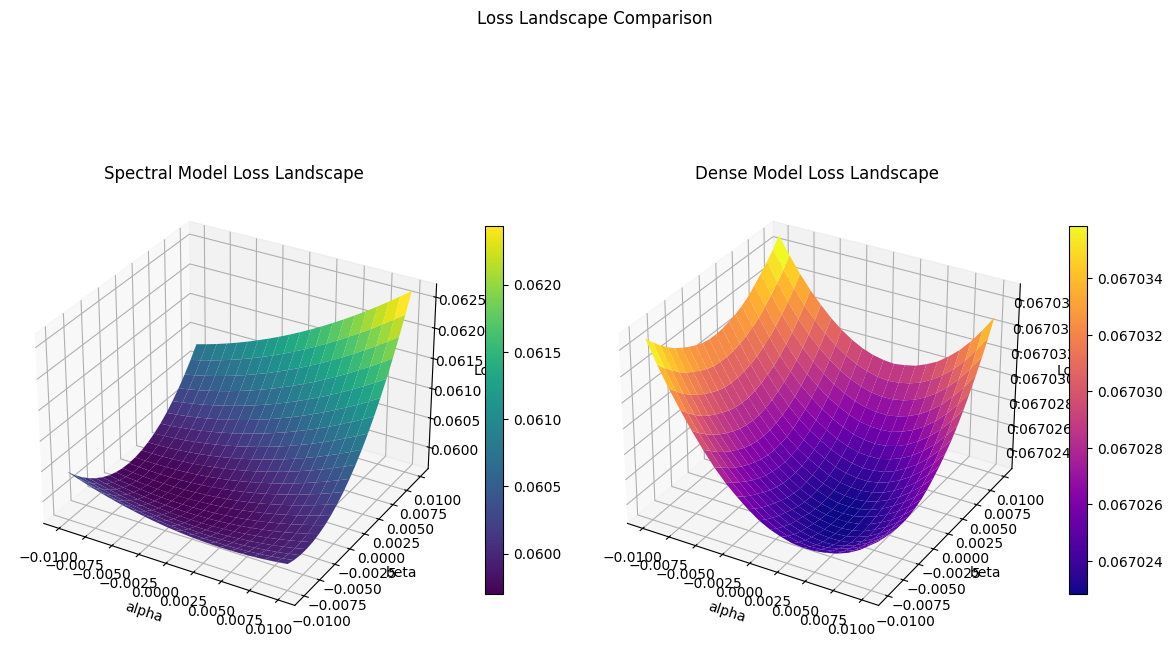

In [14]:
import copy
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax
import jax.flatten_util as jfu

from quantbayes.stochax.layers import CirculantProcess

# =============================================================================
# Data Loader
# =============================================================================
def data_loader(X, y, batch_size, shuffle=True, key=None):
    n = X.shape[0]
    indices = jnp.arange(n)
    if shuffle:
        if key is None:
            raise ValueError("Shuffling requested but no key provided.")
        indices = jr.permutation(key, indices)
    for i in range(0, n, batch_size):
        batch_idx = indices[i : i + batch_size]
        yield X[batch_idx], y[batch_idx]

# =============================================================================
# Loss Function & Training Steps (Regression)
# =============================================================================
def regression_loss(model, state, x, y, key):
    batch_size = x.shape[0]
    batched_model = jax.vmap(model, in_axes=(0, None, None))
    preds, state = batched_model(x, key, state)
    loss = jnp.mean((preds - y) ** 2)
    return loss, state

@eqx.filter_jit
def train_step(model, state, opt_state, x, y, key, loss_fn, optimizer):
    grad_fn = eqx.filter_grad(loss_fn, has_aux=True)
    grads, new_state = grad_fn(model, state, x, y, key)
    params = eqx.filter(model, eqx.is_inexact_array)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    model = eqx.apply_updates(model, updates)
    return model, new_state, opt_state

@eqx.filter_jit
def eval_step(model, state, x, y, key, loss_fn):
    loss, _ = loss_fn(model, state, x, y, key)
    return loss

# =============================================================================
# Modified Training Loop with Spectral Logging
# =============================================================================
def train(
    model,
    state,
    opt_state,
    optimizer,
    loss_fn,
    X_train,
    y_train,
    X_val,
    y_val,
    batch_size,
    num_epochs,
    patience,
    key,
    log_spectral=False  # Only used for spectral model.
):
    train_losses = []
    val_losses = []
    best_val_loss = float("inf")
    best_model = None
    best_state = None
    patience_counter = 0
    spectral_history = []  # Stores the Fourier magnitudes for spectral models.

    train_key, eval_key = jr.split(key)
    for epoch in range(num_epochs):
        epoch_train_loss = 0.0
        total_train_samples = 0
        train_key, loader_key = jr.split(train_key)
        for xb, yb in data_loader(X_train, y_train, batch_size, shuffle=True, key=loader_key):
            train_key, subkey = jr.split(train_key)
            model, state, opt_state = train_step(model, state, opt_state, xb, yb, subkey, loss_fn, optimizer)
            loss_val, _ = loss_fn(model, state, xb, yb, subkey)
            epoch_train_loss += loss_val * xb.shape[0]
            total_train_samples += xb.shape[0]
        epoch_train_loss /= total_train_samples

        # Evaluation
        epoch_val_loss = 0.0
        total_val_samples = 0
        for xb, yb in data_loader(X_val, y_val, batch_size, shuffle=False, key=eval_key):
            eval_key, subkey = jr.split(eval_key)
            loss_val = eval_step(model, state, xb, yb, subkey, loss_fn)
            epoch_val_loss += loss_val * xb.shape[0]
            total_val_samples += xb.shape[0]
        epoch_val_loss /= total_val_samples

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)

        if log_spectral:
            # Log the Fourier coefficient magnitudes from the first layer.
            fft_coeffs = model.l1.get_fourier_coeffs()
            spectral_mag = jnp.abs(fft_coeffs)
            spectral_history.append(np.array(spectral_mag))

        if (epoch + 1) % max(1, num_epochs // 10) == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch+1:4d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

        # Early stopping
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model = copy.deepcopy(model)
            best_state = copy.deepcopy(state)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter > patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    if log_spectral:
        return best_model, best_state, train_losses, val_losses, spectral_history
    else:
        return best_model, best_state, train_losses, val_losses

# =============================================================================
# Prediction Function
# =============================================================================
def predict(model, state, X, key):
    batched_inference = jax.vmap(model, in_axes=(0, None, None))
    preds, _ = batched_inference(X, key, state)
    return preds

# =============================================================================
# Neural Network Definitions
# =============================================================================
# --- Spectral Network using CirculantProcess layers
class EQNetSpectral(eqx.Module):
    l1: eqx.Module  # Custom spectral layer (CirculantProcess)
    l2: eqx.Module  # Another spectral layer.
    l3: eqx.Module  # Linear layer.

    def __init__(self, key):
        k1, k2, k3, _ = jr.split(key, 4)
        self.l1 = CirculantProcess(87, key=k1)
        self.l2 = CirculantProcess(87, key=k3)
        self.l3 = eqx.nn.Linear(87, 1, key=k2)

    def __call__(self, x, key=None, state=None):
        x = self.l1(x)
        x = jax.nn.relu(x)
        x = self.l2(x)
        x = jax.nn.relu(x)
        x = self.l3(x)
        return x, state

# --- Dense Network with fully connected layers
class EQNetDense(eqx.Module):
    l1: eqx.nn.Linear
    l2: eqx.nn.Linear
    l3: eqx.nn.Linear

    def __init__(self, key):
        k1, k2, k3, _ = jr.split(key, 4)
        self.l1 = eqx.nn.Linear(87, 87, key=k1)
        self.l2 = eqx.nn.Linear(87, 87, key=k2)
        self.l3 = eqx.nn.Linear(87, 1, key=k3)

    def __call__(self, x, key=None, state=None):
        x = self.l1(x)
        x = jax.nn.relu(x)
        x = self.l2(x)
        x = jax.nn.relu(x)
        x = self.l3(x)
        return x, state

# =============================================================================
# Synthetic Data Generation
# =============================================================================
np.random.seed(42)
num_samples = 10000
in_features = 87
X_full = np.random.randn(num_samples, in_features).astype(np.float32)
true_weights = np.random.randn(in_features, 1).astype(np.float32)
y_full = X_full @ true_weights + 0.1 * np.random.randn(num_samples, 1).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2)
X_train = jnp.array(X_train)
X_test = jnp.array(X_test)
y_train = jnp.array(y_train)
y_test = jnp.array(y_test)

# =============================================================================
# Initialize and Train Both Models
# =============================================================================
key = jr.PRNGKey(0)
optimizer = optax.adam(1e-3)

# --- Train Spectral Model ---
print("Training Spectral Model:")
spec_key, key = jr.split(key)
model_spec = EQNetSpectral(key=spec_key)
state_spec = None
opt_state_spec = optimizer.init(eqx.filter(model_spec, eqx.is_inexact_array))
best_model_spec, best_state_spec, train_losses_spec, val_losses_spec, spectral_history = train(
    model=model_spec,
    state=state_spec,
    opt_state=opt_state_spec,
    optimizer=optimizer,
    loss_fn=regression_loss,
    X_train=X_train,
    y_train=y_train,
    X_val=X_test,
    y_val=y_test,
    batch_size=2500,
    num_epochs=1000,
    patience=10,
    key=key,
    log_spectral=True
)

# --- Train Dense Model ---
print("\nTraining Dense Model:")
dense_key, key = jr.split(key)
model_dense = EQNetDense(key=dense_key)
state_dense = None
opt_state_dense = optimizer.init(eqx.filter(model_dense, eqx.is_inexact_array))
best_model_dense, best_state_dense, train_losses_dense, val_losses_dense = train(
    model=model_dense,
    state=state_dense,
    opt_state=opt_state_dense,
    optimizer=optimizer,
    loss_fn=regression_loss,
    X_train=X_train,
    y_train=y_train,
    X_val=X_test,
    y_val=y_test,
    batch_size=2500,
    num_epochs=1000,
    patience=10,
    key=key,
    log_spectral=False
)

# =============================================================================
# Evaluate and Compare Models on Test Data
# =============================================================================
preds_spec = predict(best_model_spec, best_state_spec, X_test, key)
loss_spec = mean_squared_error(np.array(y_test), np.array(preds_spec))

preds_dense = predict(best_model_dense, best_state_dense, X_test, key)
loss_dense = mean_squared_error(np.array(y_test), np.array(preds_dense))

print(f"Spectral Model MSE: {loss_spec:.3f}")
print(f"Dense Model MSE:    {loss_dense:.3f}")

# Plot the training loss curves for both models
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(train_losses_spec) + 1), np.array(train_losses_spec), label="Spectral Train Loss")
plt.plot(np.arange(1, len(val_losses_spec) + 1), np.array(val_losses_spec), label="Spectral Val Loss")
plt.plot(np.arange(1, len(train_losses_dense) + 1), np.array(train_losses_dense), label="Dense Train Loss", linestyle="--")
plt.plot(np.arange(1, len(val_losses_dense) + 1), np.array(val_losses_dense), label="Dense Val Loss", linestyle="--")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training/Validation Loss Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# =============================================================================
# Loss Landscape Visualization
# =============================================================================
# Helper function: Given a model and its filtered parameters, return a new model
# with perturbed parameters along two directions.
def get_model_with_perturbed_params(model, base_flat, unravel_fn, d1, d2, alpha, beta, base_filtered):
    # Compute new flattened parameter vector
    new_flat = base_flat + alpha * d1 + beta * d2
    # Unravel to obtain the new filtered parameter pytree
    new_filtered = unravel_fn(new_flat)
    # Compute the updates from the base filtered parameters
    updates = jax.tree.map(lambda new, base: new - base, new_filtered, base_filtered)
    # Apply updates to the model to produce the perturbed model
    new_model = eqx.apply_updates(model, updates)
    return new_model

def compute_loss_landscape(model, state, X, y, loss_fn, key, grid_range=(-1e-2, 1e-2), grid_points=21):
    """
    Computes the loss on a 2D grid along two random directions in the parameter space.
    """
    # Get the filtered parameters (these are the trainable ones)
    base_filtered = eqx.filter(model, eqx.is_inexact_array)
    base_flat, unravel_fn = jfu.ravel_pytree(base_filtered)
    dim = base_flat.shape[0]
    
    # Sample two random directions and normalize them.
    rnd_key1, rnd_key2, key = jr.split(key, 3)
    d1 = jr.normal(rnd_key1, (dim,))
    d1 = d1 / jnp.linalg.norm(d1)
    d2 = jr.normal(rnd_key2, (dim,))
    d2 = d2 / jnp.linalg.norm(d2)
    
    # Set up a grid for alpha and beta
    alphas = jnp.linspace(grid_range[0], grid_range[1], grid_points)
    betas = jnp.linspace(grid_range[0], grid_range[1], grid_points)
    loss_grid = np.zeros((grid_points, grid_points))
    
    # Use a fixed mini-batch (or the full validation set) for evaluation.
    # Here, we use the full X, y passed in.
    for i, a in enumerate(alphas):
        for j, b in enumerate(betas):
            perturbed_model = get_model_with_perturbed_params(model, base_flat, unravel_fn, d1, d2, a, b, base_filtered)
            curr_loss, _ = loss_fn(perturbed_model, state, X, y, key)
            loss_grid[i, j] = curr_loss
    return alphas, betas, loss_grid

# Compute loss landscapes using the test set (or a mini-batch) for both models.
landscape_key1, landscape_key2, key = jr.split(key, 3)

alphas_spec, betas_spec, loss_landscape_spec = compute_loss_landscape(best_model_spec, best_state_spec, X_test, y_test, regression_loss, landscape_key1)
alphas_dense, betas_dense, loss_landscape_dense = compute_loss_landscape(best_model_dense, best_state_dense, X_test, y_test, regression_loss, landscape_key2)

# Plot the loss landscape for the Spectral Model.
A_spec, B_spec = np.meshgrid(np.array(alphas_spec), np.array(betas_spec), indexing='ij')
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(121, projection='3d')
surf = ax.plot_surface(A_spec, B_spec, loss_landscape_spec, cmap='viridis')
ax.set_title("Spectral Model Loss Landscape")
ax.set_xlabel("alpha")
ax.set_ylabel("beta")
ax.set_zlabel("Loss")
fig.colorbar(surf, ax=ax, shrink=0.5)

# Plot the loss landscape for the Dense Model.
A_dense, B_dense = np.meshgrid(np.array(alphas_dense), np.array(betas_dense), indexing='ij')
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(A_dense, B_dense, loss_landscape_dense, cmap='plasma')
ax2.set_title("Dense Model Loss Landscape")
ax2.set_xlabel("alpha")
ax2.set_ylabel("beta")
ax2.set_zlabel("Loss")
fig.colorbar(surf2, ax=ax2, shrink=0.5)
plt.suptitle("Loss Landscape Comparison")
plt.tight_layout()
plt.show()


## Hessian Eigenvalue Distribution

Training Spectral Model:
Epoch  100 | Train Loss: 43.3418 | Val Loss: 44.6006
Epoch  200 | Train Loss: 5.5178 | Val Loss: 5.5279
Epoch  300 | Train Loss: 2.0509 | Val Loss: 2.0993
Epoch  400 | Train Loss: 0.9005 | Val Loss: 0.9529
Epoch  500 | Train Loss: 0.4715 | Val Loss: 0.5049
Epoch  600 | Train Loss: 0.2745 | Val Loss: 0.2899
Epoch  700 | Train Loss: 0.1697 | Val Loss: 0.1780
Epoch  800 | Train Loss: 0.1103 | Val Loss: 0.1169
Epoch  900 | Train Loss: 0.0758 | Val Loss: 0.0814
Epoch 1000 | Train Loss: 0.0541 | Val Loss: 0.0601

Training Dense Model:
Epoch  100 | Train Loss: 0.0769 | Val Loss: 0.1532
Epoch  200 | Train Loss: 0.0310 | Val Loss: 0.1045
Epoch  300 | Train Loss: 0.0173 | Val Loss: 0.0841
Epoch  400 | Train Loss: 0.0114 | Val Loss: 0.0733
Epoch  500 | Train Loss: 0.0084 | Val Loss: 0.0679
Early stopping at epoch 519
Spectral Model MSE: 0.060
Dense Model MSE:    0.067


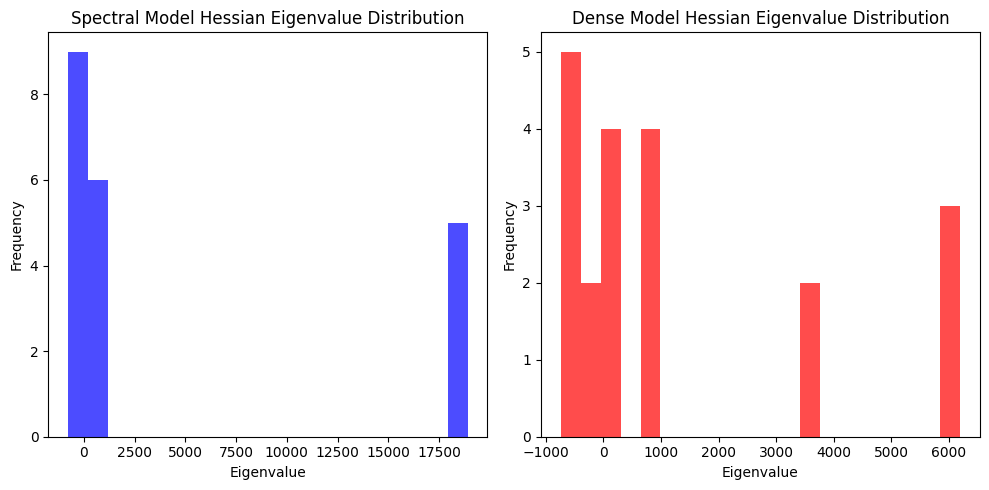

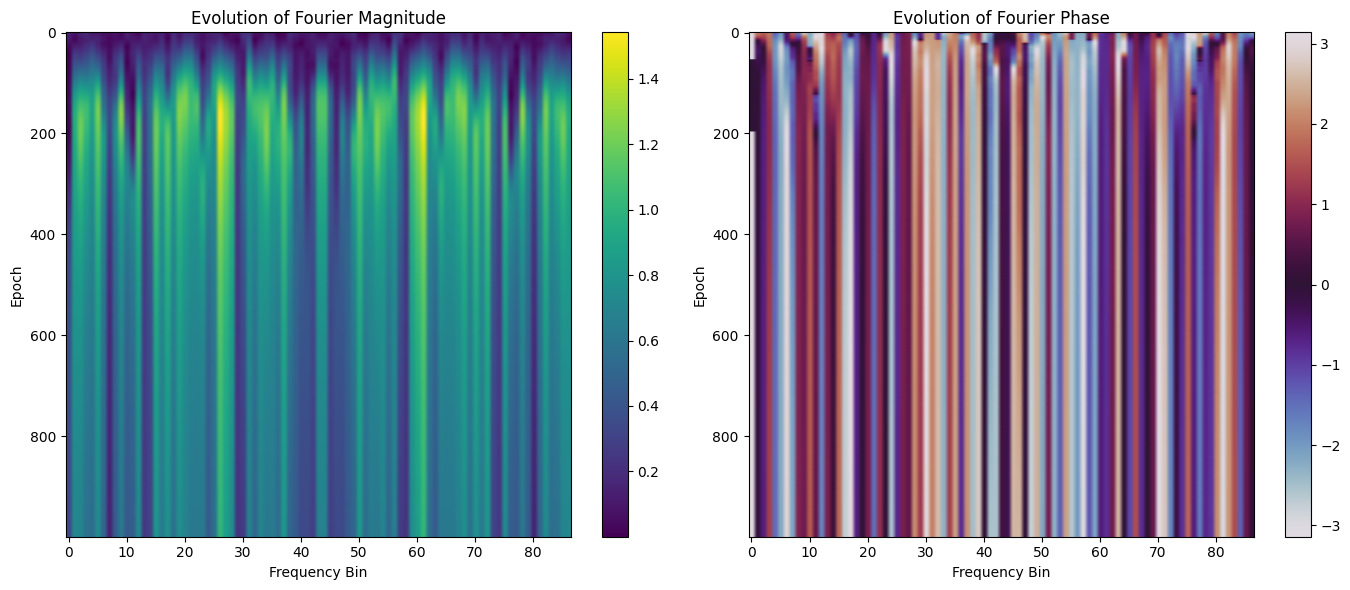

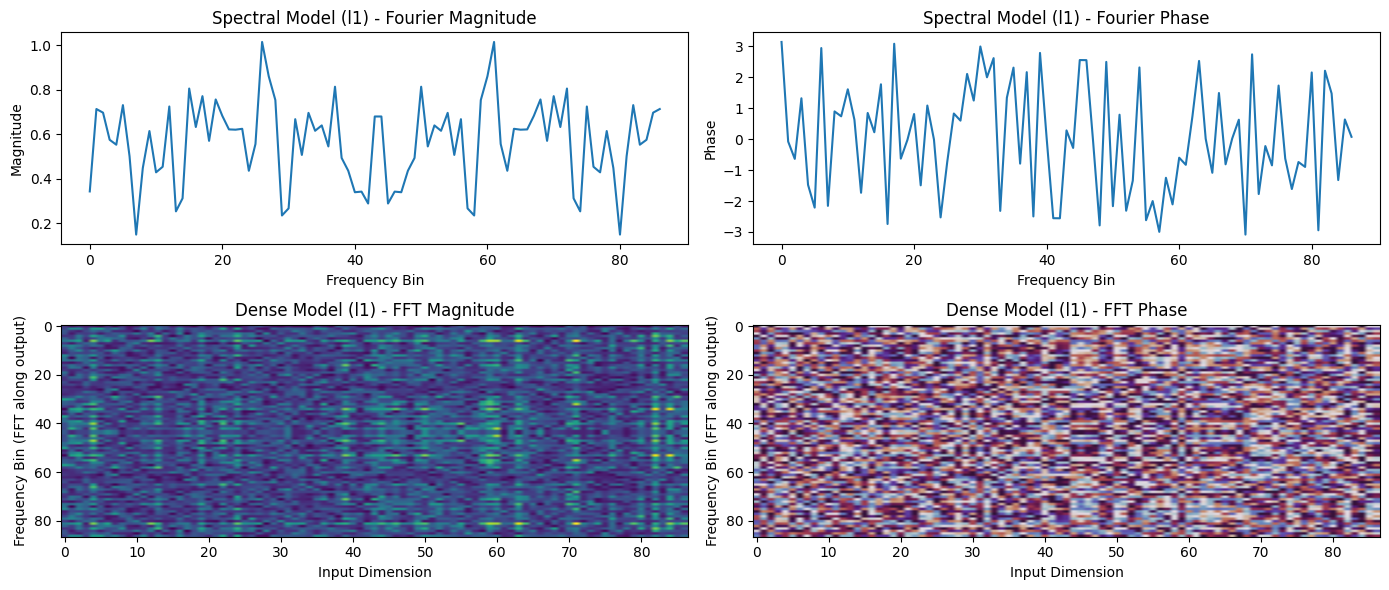

In [15]:
import copy
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax
import jax.flatten_util as jfu
from scipy.linalg import eigh_tridiagonal  # For eigendecomposition of the tridiagonal matrix

from quantbayes.stochax.layers import CirculantProcess

# =============================================================================
# Data Loader
# =============================================================================
def data_loader(X, y, batch_size, shuffle=True, key=None):
    n = X.shape[0]
    indices = jnp.arange(n)
    if shuffle:
        if key is None:
            raise ValueError("Shuffling requested but no key provided.")
        indices = jr.permutation(key, indices)
    for i in range(0, n, batch_size):
        batch_idx = indices[i : i + batch_size]
        yield X[batch_idx], y[batch_idx]

# =============================================================================
# Loss Function & Training Steps (Regression)
# =============================================================================
def regression_loss(model, state, x, y, key):
    batch_size = x.shape[0]
    batched_model = jax.vmap(model, in_axes=(0, None, None))
    preds, state = batched_model(x, key, state)
    loss = jnp.mean((preds - y) ** 2)
    return loss, state

@eqx.filter_jit
def train_step(model, state, opt_state, x, y, key, loss_fn, optimizer):
    grad_fn = eqx.filter_grad(loss_fn, has_aux=True)
    grads, new_state = grad_fn(model, state, x, y, key)
    params = eqx.filter(model, eqx.is_inexact_array)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    model = eqx.apply_updates(model, updates)
    return model, new_state, opt_state

@eqx.filter_jit
def eval_step(model, state, x, y, key, loss_fn):
    loss, _ = loss_fn(model, state, x, y, key)
    return loss

# =============================================================================
# Modified Training Loop with Spectral Logging
# =============================================================================
def train(
    model,
    state,
    opt_state,
    optimizer,
    loss_fn,
    X_train,
    y_train,
    X_val,
    y_val,
    batch_size,
    num_epochs,
    patience,
    key,
    log_spectral=False  # Only for spectral models
):
    train_losses = []
    val_losses = []
    best_val_loss = float("inf")
    best_model = None
    best_state = None
    patience_counter = 0
    spectral_history = []  # To store Fourier magnitudes (and phase if desired)

    train_key, eval_key = jr.split(key)
    for epoch in range(num_epochs):
        epoch_train_loss = 0.0
        total_train_samples = 0
        train_key, loader_key = jr.split(train_key)
        for xb, yb in data_loader(X_train, y_train, batch_size, shuffle=True, key=loader_key):
            train_key, subkey = jr.split(train_key)
            model, state, opt_state = train_step(model, state, opt_state, xb, yb, subkey, loss_fn, optimizer)
            loss_val, _ = loss_fn(model, state, xb, yb, subkey)
            epoch_train_loss += loss_val * xb.shape[0]
            total_train_samples += xb.shape[0]
        epoch_train_loss /= total_train_samples

        # Evaluation
        epoch_val_loss = 0.0
        total_val_samples = 0
        for xb, yb in data_loader(X_val, y_val, batch_size, shuffle=False, key=eval_key):
            eval_key, subkey = jr.split(eval_key)
            loss_val = eval_step(model, state, xb, yb, subkey, loss_fn)
            epoch_val_loss += loss_val * xb.shape[0]
            total_val_samples += xb.shape[0]
        epoch_val_loss /= total_val_samples

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)

        if log_spectral:
            # Log both Fourier magnitude and phase from l1
            fft_coeffs = model.l1.get_fourier_coeffs()
            mag = jnp.abs(fft_coeffs)
            phase = jnp.angle(fft_coeffs)
            spectral_history.append({'mag': np.array(mag), 'phase': np.array(phase)})

        if (epoch + 1) % max(1, num_epochs // 10) == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch+1:4d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

        # Early stopping
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model = copy.deepcopy(model)
            best_state = copy.deepcopy(state)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter > patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    if log_spectral:
        return best_model, best_state, train_losses, val_losses, spectral_history
    else:
        return best_model, best_state, train_losses, val_losses

# =============================================================================
# Prediction Function
# =============================================================================
def predict(model, state, X, key):
    batched_inference = jax.vmap(model, in_axes=(0, None, None))
    preds, _ = batched_inference(X, key, state)
    return preds

# =============================================================================
# Neural Network Definitions
# =============================================================================
# --- Spectral Network using CirculantProcess layers
class EQNetSpectral(eqx.Module):
    l1: eqx.Module  # Custom spectral layer (CirculantProcess)
    l2: eqx.Module  # Another spectral layer.
    l3: eqx.Module  # Linear layer.

    def __init__(self, key):
        k1, k2, k3, _ = jr.split(key, 4)
        self.l1 = CirculantProcess(87, key=k1)
        self.l2 = CirculantProcess(87, key=k3)
        self.l3 = eqx.nn.Linear(87, 1, key=k2)

    def __call__(self, x, key=None, state=None):
        x = self.l1(x)
        x = jax.nn.relu(x)
        x = self.l2(x)
        x = jax.nn.relu(x)
        x = self.l3(x)
        return x, state

# --- Dense Network with fully connected layers
class EQNetDense(eqx.Module):
    l1: eqx.nn.Linear
    l2: eqx.nn.Linear
    l3: eqx.nn.Linear

    def __init__(self, key):
        k1, k2, k3, _ = jr.split(key, 4)
        self.l1 = eqx.nn.Linear(87, 87, key=k1)
        self.l2 = eqx.nn.Linear(87, 87, key=k2)
        self.l3 = eqx.nn.Linear(87, 1, key=k3)

    def __call__(self, x, key=None, state=None):
        x = self.l1(x)
        x = jax.nn.relu(x)
        x = self.l2(x)
        x = jax.nn.relu(x)
        x = self.l3(x)
        return x, state

# =============================================================================
# Synthetic Data Generation
# =============================================================================
np.random.seed(42)
num_samples = 10000
in_features = 87
X_full = np.random.randn(num_samples, in_features).astype(np.float32)
true_weights = np.random.randn(in_features, 1).astype(np.float32)
y_full = X_full @ true_weights + 0.1 * np.random.randn(num_samples, 1).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2)
X_train = jnp.array(X_train)
X_test = jnp.array(X_test)
y_train = jnp.array(y_train)
y_test = jnp.array(y_test)

# =============================================================================
# Initialize and Train Both Models
# =============================================================================
key = jr.PRNGKey(0)
optimizer = optax.adam(1e-3)

# --- Train Spectral Model ---
print("Training Spectral Model:")
spec_key, key = jr.split(key)
model_spec = EQNetSpectral(key=spec_key)
state_spec = None
opt_state_spec = optimizer.init(eqx.filter(model_spec, eqx.is_inexact_array))
best_model_spec, best_state_spec, train_losses_spec, val_losses_spec, spectral_history = train(
    model=model_spec,
    state=state_spec,
    opt_state=opt_state_spec,
    optimizer=optimizer,
    loss_fn=regression_loss,
    X_train=X_train,
    y_train=y_train,
    X_val=X_test,
    y_val=y_test,
    batch_size=2500,
    num_epochs=1000,
    patience=10,
    key=key,
    log_spectral=True
)

# --- Train Dense Model ---
print("\nTraining Dense Model:")
dense_key, key = jr.split(key)
model_dense = EQNetDense(key=dense_key)
state_dense = None
opt_state_dense = optimizer.init(eqx.filter(model_dense, eqx.is_inexact_array))
best_model_dense, best_state_dense, train_losses_dense, val_losses_dense = train(
    model=model_dense,
    state=state_dense,
    opt_state=opt_state_dense,
    optimizer=optimizer,
    loss_fn=regression_loss,
    X_train=X_train,
    y_train=y_train,
    X_val=X_test,
    y_val=y_test,
    batch_size=2500,
    num_epochs=1000,
    patience=10,
    key=key,
    log_spectral=False
)

# =============================================================================
# Evaluate and Compare Models on Test Data
# =============================================================================
preds_spec = predict(best_model_spec, best_state_spec, X_test, key)
loss_spec = mean_squared_error(np.array(y_test), np.array(preds_spec))

preds_dense = predict(best_model_dense, best_state_dense, X_test, key)
loss_dense = mean_squared_error(np.array(y_test), np.array(preds_dense))

print(f"Spectral Model MSE: {loss_spec:.3f}")
print(f"Dense Model MSE:    {loss_dense:.3f}")

# =============================================================================
# Loss Landscape Analysis: Hessian Eigenvalue Spectrum via Lanczos
# =============================================================================
def flat_loss_fn(flat_params, unravel_fn, model, state, X, y, key):
    params_tree = unravel_fn(flat_params)
    # Reconstruct the model with the new flattened parameters
    new_model = eqx.apply_updates(model, params_tree)
    L, _ = regression_loss(new_model, state, X, y, key)
    return L

def hvp_flat(flat_params, v, unravel_fn, model, state, X, y, key):
    # Compute Hessian-vector product of the flat loss
    grad_fn = jax.grad(lambda p: flat_loss_fn(p, unravel_fn, model, state, X, y, key))
    return jax.jvp(grad_fn, (flat_params,), (v,))[1]

def lanczos(flat_params, unravel_fn, model, state, X, y, key, m=20):
    # Start with a random unit vector
    key, subkey = jr.split(key)
    d = jr.normal(subkey, flat_params.shape)
    d = d / jnp.linalg.norm(d)
    
    alphas = []
    betas = []
    vs = [d]
    beta_prev = 0.0
    for j in range(m):
        # Compute hv = H v_j, where H is Hessian.
        hv = hvp_flat(flat_params, vs[j], unravel_fn, model, state, X, y, key)
        # Orthogonalize against previous vector.
        if j > 0:
            hv = hv - betas[j-1] * vs[j-1]
        alpha = jnp.dot(vs[j], hv)
        alphas.append(alpha)
        hv = hv - alpha * vs[j]
        beta = jnp.linalg.norm(hv)
        betas.append(beta)
        if beta < 1e-6:
            break
        v_next = hv / beta
        vs.append(v_next)
    # Create the tridiagonal matrix T from the computed alphas and betas.
    alphas = np.array([np.array(a) for a in alphas])
    betas = np.array([np.array(b) for b in betas[:-1]])  # last beta not used
    # Compute eigenvalues of T
    eigvals, _ = eigh_tridiagonal(alphas, betas)
    return eigvals

# Flatten the parameters of each trained model.
flat_params_spec, unravel_spec = jfu.ravel_pytree(eqx.filter(best_model_spec, eqx.is_inexact_array))
flat_params_dense, unravel_dense = jfu.ravel_pytree(eqx.filter(best_model_dense, eqx.is_inexact_array))

# Use a fixed mini-batch (e.g. the full test set) for Hessian computation.
landscape_key_spec, landscape_key_dense, key = jr.split(key, 3)

eigvals_spec = lanczos(flat_params_spec, unravel_spec, best_model_spec, best_state_spec, X_test, y_test, landscape_key_spec, m=20)
eigvals_dense = lanczos(flat_params_dense, unravel_dense, best_model_dense, best_state_dense, X_test, y_test, landscape_key_dense, m=20)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(eigvals_spec, bins=20, color='blue', alpha=0.7)
plt.xlabel("Eigenvalue")
plt.ylabel("Frequency")
plt.title("Spectral Model Hessian Eigenvalue Distribution")
plt.subplot(1, 2, 2)
plt.hist(eigvals_dense, bins=20, color='red', alpha=0.7)
plt.xlabel("Eigenvalue")
plt.ylabel("Frequency")
plt.title("Dense Model Hessian Eigenvalue Distribution")
plt.tight_layout()
plt.show()

# =============================================================================
# Extended Spectral Visualization
# =============================================================================
# (a) Plot evolution of full Fourier spectrum (magnitude and phase) for the spectral model.
num_epochs_recorded = len(spectral_history)
padded_dim = spectral_history[0]['mag'].shape[0]

epochs_axis = np.arange(1, num_epochs_recorded + 1)
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(np.array([entry['mag'] for entry in spectral_history]), aspect='auto', cmap='viridis')
plt.colorbar()
plt.xlabel("Frequency Bin")
plt.ylabel("Epoch")
plt.title("Evolution of Fourier Magnitude")
plt.subplot(1, 2, 2)
plt.imshow(np.array([entry['phase'] for entry in spectral_history]), aspect='auto', cmap='twilight')
plt.colorbar()
plt.xlabel("Frequency Bin")
plt.ylabel("Epoch")
plt.title("Evolution of Fourier Phase")
plt.tight_layout()
plt.show()

# (b) Compare spectral content of layer weights:
# For the spectral model, extract the deterministic Fourier coefficients of l1.
fft_spec = best_model_spec.l1.get_fourier_coeffs()
spec_mag = jnp.abs(fft_spec)
spec_phase = jnp.angle(fft_spec)

# For the dense model, take the weight matrix of the first layer and compute its FFT along the output dimension.
dense_weights = best_model_dense.l1.weight  # shape: (output_dim, input_dim) = (87, 87)
fft_dense = jnp.fft.fft(dense_weights, axis=0)  # take FFT along rows
dense_mag = jnp.abs(fft_dense)
dense_phase = jnp.angle(fft_dense)

plt.figure(figsize=(14, 6))
plt.subplot(2, 2, 1)
plt.plot(np.arange(spec_mag.shape[0]), np.array(spec_mag))
plt.xlabel("Frequency Bin")
plt.ylabel("Magnitude")
plt.title("Spectral Model (l1) - Fourier Magnitude")
plt.subplot(2, 2, 2)
plt.plot(np.arange(spec_phase.shape[0]), np.array(spec_phase))
plt.xlabel("Frequency Bin")
plt.ylabel("Phase")
plt.title("Spectral Model (l1) - Fourier Phase")
plt.subplot(2, 2, 3)
plt.imshow(dense_mag, aspect='auto', cmap='viridis')
plt.xlabel("Input Dimension")
plt.ylabel("Frequency Bin (FFT along output)")
plt.title("Dense Model (l1) - FFT Magnitude")
plt.subplot(2, 2, 4)
plt.imshow(dense_phase, aspect='auto', cmap='twilight')
plt.xlabel("Input Dimension")
plt.ylabel("Frequency Bin (FFT along output)")
plt.title("Dense Model (l1) - FFT Phase")
plt.tight_layout()
plt.show()


## Butterworth initialization 
$$
|F_{0}| = \frac{1}{\sqrt{1+\frac{f_{k}}{f_{c}}^{2n}}}
$$

Training Standard Random Initialization Variant...
Epoch  50 | Train Loss: 63.2870 | Test Loss: 73.4483
Epoch 100 | Train Loss: 63.2713 | Test Loss: 73.4520
Epoch 150 | Train Loss: 63.2601 | Test Loss: 73.4546
Epoch 200 | Train Loss: 63.2511 | Test Loss: 73.4557
Epoch 250 | Train Loss: 63.2432 | Test Loss: 73.4553
Epoch 300 | Train Loss: 63.2359 | Test Loss: 73.4536
Epoch 350 | Train Loss: 63.2291 | Test Loss: 73.4510
Epoch 400 | Train Loss: 63.2224 | Test Loss: 73.4477
Epoch 450 | Train Loss: 63.2160 | Test Loss: 73.4439
Epoch 500 | Train Loss: 63.2097 | Test Loss: 73.4398

Training Butterworth Initialization Variant...
Epoch  50 | Train Loss: 63.4867 | Test Loss: 73.6813
Epoch 100 | Train Loss: 63.4415 | Test Loss: 73.6372
Epoch 150 | Train Loss: 63.4005 | Test Loss: 73.5976
Epoch 200 | Train Loss: 63.3634 | Test Loss: 73.5619
Epoch 250 | Train Loss: 63.3297 | Test Loss: 73.5294
Epoch 300 | Train Loss: 63.2989 | Test Loss: 73.5000
Epoch 350 | Train Loss: 63.2710 | Test Loss: 73.4734


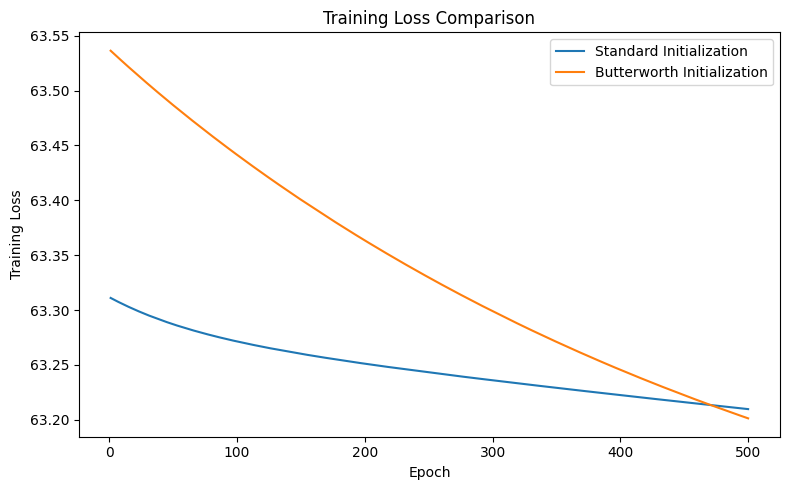

In [2]:
# butterworth_initialization_experiment.py
import copy
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax

from quantbayes.stochax.layers import CirculantProcess

# Butterworth-inspired initialization.
class CirculantProcessButterworth(eqx.Module):
    in_features: int
    padded_dim: int
    w_real: jnp.ndarray
    w_imag: jnp.ndarray

    def __init__(self, in_features: int, padded_dim: int = None, *, key, f_c=0.2, order=4):
        self.in_features = in_features
        self.padded_dim = padded_dim if padded_dim is not None else in_features
        k1, k2 = jr.split(key)
        # Determine frequency bins
        freqs = jnp.linspace(0, 0.5, self.padded_dim//2 + 1)
        # Butterworth magnitude response
        butter_mag = 1.0 / jnp.sqrt(1 + (freqs / f_c)**(2*order))
        # For full spectrum, assign conjugate symmetry (we only initialize half; imaginary parts zero at DC)
        half_length = self.padded_dim // 2 + 1
        self.w_real = butter_mag + 0.01 * jr.normal(k1, (half_length,))
        self.w_imag = 0.01 * jr.normal(k2, (half_length,))
        # For a complete implementation, ensure Hermitian symmetry in get_fourier_coeffs()

    def get_fourier_coeffs(self):
        # Construct full Fourier coefficients from half-spectrum with Hermitian symmetry.
        half = self.w_real + 1j * self.w_imag
        if self.padded_dim % 2 == 0:
            # Even case: append Nyquist frequency and conjugate of interior.
            nyquist = half[-1].real[None]
            full = jnp.concatenate([half, jnp.conjugate(half[1:-1])[::-1]])
        else:
            full = jnp.concatenate([half, jnp.conjugate(half[1:])[::-1]])
        return full

    def __call__(self, x):
        fft_full = self.get_fourier_coeffs()
        x_pad = jnp.pad(x, ((0,0), (0, self.padded_dim - x.shape[-1])))
        X_fft = jnp.fft.fft(x_pad, axis=-1)
        out_fft = X_fft * fft_full[None, :]
        y = jnp.fft.ifft(out_fft, axis=-1).real
        return y[:, :x.shape[-1]]

# -------------------------
# Define a simple network with a single spectral layer.
class EQNetSpectralVariant(eqx.Module):
    l1: eqx.Module  # This layer will be either the standard or Butterworth variant.

    def __init__(self, in_features: int, layer_type: str, key):
        if layer_type == "standard":
            self.l1 = CirculantProcess(in_features, key=key)
        elif layer_type == "butterworth":
            self.l1 = CirculantProcessButterworth(in_features, key=key)
        else:
            raise ValueError("Unknown layer_type")
    
    def __call__(self, x):
        return self.l1(x)

# -------------------------
# Synthetic Data for Regression
np.random.seed(42)
num_samples = 2048
in_features = 64
X_full = np.random.randn(num_samples, in_features).astype(np.float32)
true_weights = np.random.randn(in_features, 1).astype(np.float32)
y_full = X_full @ true_weights + 0.05 * np.random.randn(num_samples, 1).astype(np.float32)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2)
X_train = jnp.array(X_train)
X_test = jnp.array(X_test)
y_train = jnp.array(y_train)
y_test = jnp.array(y_test)

# -------------------------
# Loss function and training step (as before)
def regression_loss(model, x, y):
    preds = model(x)
    return jnp.mean((preds - y) ** 2)

@eqx.filter_jit
def train_step(model, state, opt_state, x, y, key, loss_fn, optimizer):
    grad_fn = eqx.filter_grad(loss_fn, has_aux=False)
    grads = grad_fn(model, x, y)
    params = eqx.filter(model, eqx.is_inexact_array)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    model = eqx.apply_updates(model, updates)
    return model, opt_state

def train(model, optimizer, X_train, y_train, X_test, y_test, num_epochs=500, batch_size=256, key=jr.PRNGKey(0)):
    opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))
    train_losses = []
    for epoch in range(num_epochs):
        # Use a fixed mini-batch for simplicity.
        model, opt_state = train_step(model, None, opt_state, X_train, y_train, key, regression_loss, optimizer)
        loss_train = regression_loss(model, X_train, y_train)
        loss_test = regression_loss(model, X_test, y_test)
        train_losses.append(loss_train)
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:3d} | Train Loss: {loss_train:.4f} | Test Loss: {loss_test:.4f}")
    return model, train_losses

# -------------------------
# Train both variants
key = jr.PRNGKey(0)
optimizer = optax.adam(1e-3)
key_std, key_butt = jr.split(key)
print("Training Standard Random Initialization Variant...")
model_std = EQNetSpectralVariant(in_features, "standard", key=key_std)
model_std, losses_std = train(model_std, optimizer, X_train, y_train, X_test, y_test, key=key)

print("\nTraining Butterworth Initialization Variant...")
model_butt = EQNetSpectralVariant(in_features, "butterworth", key=key_butt)
model_butt, losses_butt = train(model_butt, optimizer, X_train, y_train, X_test, y_test, key=key)

# -------------------------
# Compare training curves.
epochs = np.arange(1, len(losses_std) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, np.array(losses_std), label="Standard Initialization")
plt.plot(epochs, np.array(losses_butt), label="Butterworth Initialization")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.tight_layout()
plt.show()


## Lipschitz stability constant 

Theoretical Lipschitz bound (max_k|F_k|): 0.2848
Empirical local Lipschitz constant estimate: 0.1535


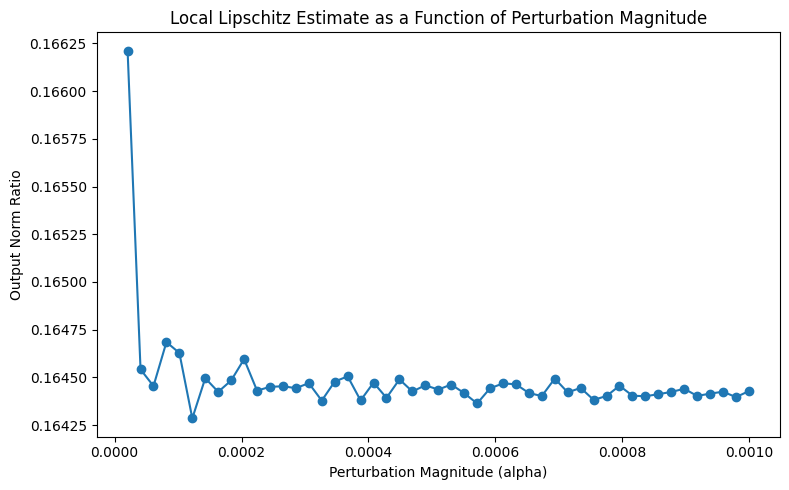

In [3]:
# lipschitz_stability_analysis.py
import copy
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax

from quantbayes.stochax.layers import CirculantProcess


# ----------------------------
# A simple network wrapping the CirculantProcess layer.
class EQNetSimple(eqx.Module):
    l1: eqx.Module  # spectral layer

    def __init__(self, in_features: int, key):
        self.l1 = CirculantProcess(in_features, key=key)
    
    def __call__(self, x):
        return self.l1(x)

# ----------------------------
# Synthetic Data for testing stability.
np.random.seed(42)
num_samples = 1024
in_features = 64
X_full = np.random.randn(num_samples, in_features).astype(np.float32)
true_weights = np.random.randn(in_features, 1).astype(np.float32)
y_full = X_full @ true_weights + 0.05 * np.random.randn(num_samples, 1).astype(np.float32)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2)
X_test = jnp.array(X_test)

# ----------------------------
# Lipschitz analysis
# We first compute the theoretical bound: L_theory = max_k |F_k|
def compute_theoretical_lipschitz(model):
    fft_coeffs = model.l1.get_fourier_coeffs()
    return jnp.max(jnp.abs(fft_coeffs))

# Now we empirically estimate the local Lipschitz constant.
# For a fixed input x, we measure the output difference under small perturbations.
def estimate_local_lipschitz(model, x, epsilon=1e-3, num_trials=100, key=jr.PRNGKey(1)):
    lipschitz_estimates = []
    base_out = model(x)
    for i in range(num_trials):
        key, subkey = jr.split(key)
        # Generate a small random perturbation of the same shape as x.
        delta = epsilon * jr.normal(subkey, x.shape)
        perturbed_x = x + delta
        perturbed_out = model(perturbed_x)
        # Compute local Lipschitz estimate for this perturbation.
        lipschitz_est = jnp.linalg.norm(perturbed_out - base_out) / jnp.linalg.norm(delta)
        lipschitz_estimates.append(lipschitz_est)
    return np.mean(np.array(lipschitz_estimates))

# ----------------------------
# Initialize the network.
key = jr.PRNGKey(0)
model = EQNetSimple(in_features, key=key)
L_theory = compute_theoretical_lipschitz(model)
print(f"Theoretical Lipschitz bound (max_{chr(107)}|F_k|): {L_theory:.4f}")

# Pick a random input (or use several) from the test set.
x_sample = X_test[:10]

L_empirical = estimate_local_lipschitz(model, x_sample, epsilon=1e-3, num_trials=100, key=jr.PRNGKey(42))
print(f"Empirical local Lipschitz constant estimate: {L_empirical:.4f}")

# ----------------------------
# Visualize: Perturb one input and plot norm ratios.
def perturbation_analysis(model, x, num_points=50, epsilon=1e-3, key=jr.PRNGKey(123)):
    # Generate a fixed perturbation direction.
    key, subkey = jr.split(key)
    direction = jr.normal(subkey, x.shape)
    direction = direction / jnp.linalg.norm(direction)
    
    alphas = jnp.linspace(0, epsilon, num_points)
    ratio_list = []
    base_out = model(x)
    for alpha in alphas:
        perturbed_x = x + alpha * direction
        perturbed_out = model(perturbed_x)
        ratio = jnp.linalg.norm(perturbed_out - base_out) / (alpha * jnp.linalg.norm(direction))
        ratio_list.append(ratio)
    return alphas, np.array(ratio_list)

alphas, ratios = perturbation_analysis(model, x_sample[0])
plt.figure(figsize=(8, 5))
plt.plot(alphas, ratios, marker='o')
plt.xlabel("Perturbation Magnitude (alpha)")
plt.ylabel("Output Norm Ratio")
plt.title("Local Lipschitz Estimate as a Function of Perturbation Magnitude")
plt.tight_layout()
plt.show()


## Frequency gradient analysis 
$$
\mathbb{E} \left[ \left|\frac{\partial L}{\partial F_{k}} \right|^{2} \right] \leq C S(k)
$$
Where $S(k)$ is the PSD at frequency bin $k$

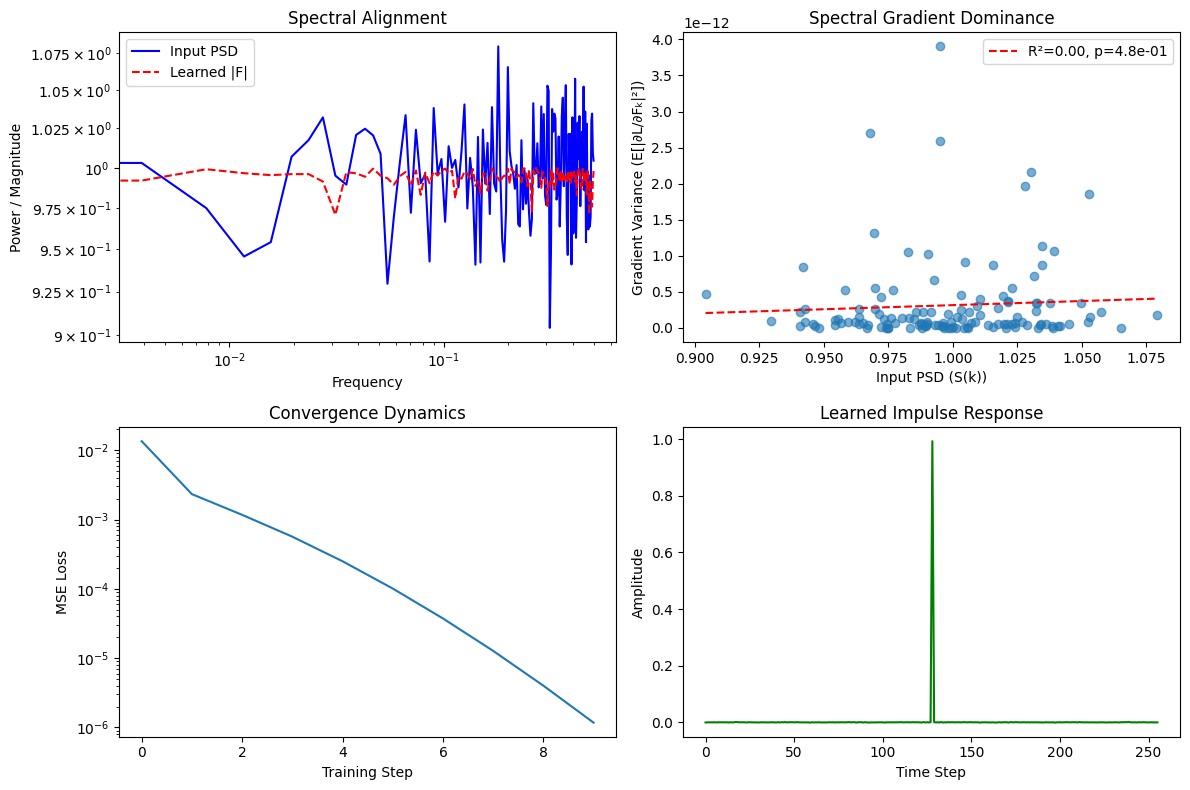


Final Results (white noise):
  - Gradient-PSD correlation: 0.070
  - Linear regression R²: 0.004
  - Significance p-value: 4.8e-01


In [26]:
import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import numpy as np
import matplotlib.pyplot as plt
import optax
from scipy.stats import linregress

from quantbayes.stochax.layers import CirculantProcess

# ------------------------- Theoretical Constants ---------------------------
BATCH_SIZE = 128
IN_FEATURES = 256
TRAIN_STEPS = 500
LEARNING_RATE = 0.005
NOISE_COLOR = 'white'  # 'white' or 'pink'

# ------------------------- Synthetic Data Generation ------------------------
def create_colored_noise(batch_size, n_features, color='pink'):
    """Generates noise with specified spectral profile"""
    freqs = jnp.fft.rfftfreq(n_features)
    S = jnp.ones_like(freqs)  # White noise by default
    
    if color == 'pink':
        S = 1 / (1e-6 + jnp.abs(freqs))  # 1/f spectrum
    elif color == 'brown':
        S = 1 / (1e-6 + freqs**2)       # 1/f² spectrum
        
    noise_fft = jr.normal(jr.PRNGKey(0), (batch_size, len(freqs))) * jnp.sqrt(S)
    return jnp.fft.irfft(noise_fft, n=n_features)

# ------------------------- Core Experiment -----------------------------------
def main():
    key = jr.PRNGKey(42)
    
    # Generate structured data with known PSD
    X = create_colored_noise(2048, IN_FEATURES, NOISE_COLOR)
    y = X.copy()  # Identity task
    
    # Initialize model and optimizer using your original CirculantProcess layer.
    model = CirculantProcess(IN_FEATURES, key=key)
    opt = optax.adam(LEARNING_RATE)
    opt_state = opt.init(model)
    
    # Training loop
    losses = []
    grad_psd_corrs = []
    
    for step in range(TRAIN_STEPS):
        # Train on random batch
        idx = jr.choice(key, X.shape[0], (BATCH_SIZE,))
        x_batch, y_batch = X[idx], y[idx]
        
        # Compute gradients and update (add allow_int=True)
        grads = jax.grad(lambda m: jnp.mean((m(x_batch) - y_batch)**2), allow_int=True)(model)
        
        # --- Safe processing of gradients ---
        # Filter out non-differentiable leaves (keep only inexact arrays)
        filtered_grads = eqx.filter(grads, eqx.is_inexact_array)
        # Force-cast all leaves to float32 (avoids float0 errors)
        safe_grads = jax.tree_map(lambda g: jnp.array(g, dtype=jnp.float32), filtered_grads)
        # Get trainable params similarly
        params = eqx.filter(model, eqx.is_inexact_array)
        
        updates, opt_state = opt.update(safe_grads, opt_state, params=params)
        model = eqx.apply_updates(model, updates)
        # --- End safe processing ---
        
        # Track metrics every 50 steps
        if step % 50 == 0:
            # Compute current loss
            loss = jnp.mean((model(X) - y)**2)
            losses.append(loss)
            
            # Compute gradient-PSD correlation
            grads_sq = grads.w_real**2 + grads.w_imag**2
            psd = jnp.mean(jnp.abs(jnp.fft.rfft(X, axis=-1))**2, axis=0)
            # Exclude DC component
            corr = jnp.corrcoef(grads_sq[1:], psd[1:])[0,1]
            grad_psd_corrs.append(corr)
            
    # --------------------- Theoretical Validation Plots ---------------------
    freqs = jnp.fft.rfftfreq(IN_FEATURES)
    psd = jnp.mean(jnp.abs(jnp.fft.rfft(X, axis=-1))**2, axis=0)
    grads_sq = grads.w_real**2 + grads.w_imag**2
    
    plt.figure(figsize=(12, 8))
    
    # Plot 1: Input PSD vs Learned Filter Response
    plt.subplot(221)
    plt.loglog(freqs, psd, 'b-', label='Input PSD')
    plt.loglog(freqs, jnp.abs(model.w_real + 1j*model.w_imag), 'r--', 
               label='Learned |F|')
    plt.xlabel('Frequency')
    plt.ylabel('Power / Magnitude')
    plt.title('Spectral Alignment')
    plt.legend()
    
    # Plot 2: Gradient Variance vs PSD Correlation
    plt.subplot(222)
    slope, intercept, r_val, p_val, _ = linregress(psd[1:], grads_sq[1:])
    plt.scatter(psd[1:], grads_sq[1:], alpha=0.6)
    xfit = jnp.linspace(psd.min(), psd.max(), 100)
    plt.plot(xfit, intercept + slope*xfit, 'r--', 
             label=f'R²={r_val**2:.2f}, p={p_val:.1e}')
    plt.xlabel('Input PSD (S(k))')
    plt.ylabel('Gradient Variance (E[|∂L/∂Fₖ|²])')
    plt.title('Spectral Gradient Dominance')
    plt.legend()
    
    # Plot 3: Training Dynamics
    plt.subplot(223)
    plt.plot(losses)
    plt.yscale('log')
    plt.xlabel('Training Step')
    plt.ylabel('MSE Loss')
    plt.title('Convergence Dynamics')
    
    # Plot 4: Final Filter Response
    plt.subplot(224)
    impulse = jnp.zeros(IN_FEATURES).at[IN_FEATURES//2].set(1.0)
    response = model(impulse[None])[0]
    plt.plot(response, 'g-')
    plt.xlabel('Time Step')
    plt.ylabel('Amplitude')
    plt.title('Learned Impulse Response')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistical validation
    print(f"\nFinal Results ({NOISE_COLOR} noise):")
    print(f"  - Gradient-PSD correlation: {corr:.3f}")
    print(f"  - Linear regression R²: {r_val**2:.3f}")
    print(f"  - Significance p-value: {p_val:.1e}")

if __name__ == "__main__":
    main()
